### Validation

Validation acts as a hard guardrail that prevents the LLM from hallucinating or ignoring business logic.
It provides structured feedback (the ValueError) directly back to the model, allowing it to "self-heal."
Without this, the agent might proceed with an illegal transaction, leading to severe regulatory failures.

### Use Case: Secure Wire Transfers

A banking assistant must process international wire transfers based on user requests.
However, it must strictly prevent transfers to "Sanctioned Countries" to remain compliant.
The system needs a way to catch these restricted destinations and force the model to ask for a valid country.



In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition, ValidationNode
from pydantic import BaseModel, Field, field_validator
from typing import Literal, Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langchain.tools import tool
from langchain_core.messages import ToolMessage, HumanMessage

In [15]:
import os


# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0",cohere.command-r-plus-v1:0 region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id= "anthropic.claude-3-sonnet-20240229-v1:0",          #"amazon.nova-lite-v1:0", 
                          region_name="us-east-1",
                          temperature=0.5, 
                          max_tokens=1000)

llm.invoke('hi').content

'Hello!'

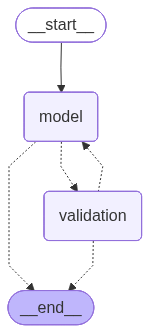

In [19]:
# Define the Schema with Validation Logic
class WireTransfer(BaseModel):
    destination_country: str
    amount: float

    @field_validator("destination_country")
    def check_sanctions(cls, v):
        restricted = ["Atlantis", "Mordor", "Narnia"]
        if v.title() in restricted:
            raise ValueError(f"{v} is a restricted destination. Please provide a sanctioned-free country.")
        return v

# Setup the State and Graph
builder = StateGraph(Annotated[list, add_messages])

llm_with_tool = llm.bind_tools([WireTransfer])

builder.add_node("model", lambda state: llm_with_tool.invoke(state))
builder.add_node("validation", ValidationNode([WireTransfer]))

#  Define Logic Flow
builder.add_edge(START, "model")

def should_validate(state: list) -> Literal["validation", "__end__"]:
    if state[-1].tool_calls:
        return "validation"
    return END

builder.add_conditional_edges("model", should_validate)

def should_reprompt(state: list) -> Literal["model", "__end__"]:
    # Look for the most recent tool output to see if it's an error
    for msg in reversed(state):
        if msg.type == "tool":
            if msg.additional_kwargs.get("is_error") or "Error" in msg.content:
                return "model"
            break
    return END

builder.add_conditional_edges("validation", should_reprompt)

graph = builder.compile()
builder.compile()


In [20]:
#  Execute
# If the user says "Send $500 to India", the graph will run successfully
# until the model chooses a valid country.
res = graph.invoke([("user", "I want to send $500 to India.")])

for msg in res:
    msg.pretty_print()

================================ Human Message =================================

I want to send $500 to India.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Okay, to send $500 to India, we can use the WireTransfer tool:'}, {'type': 'tool_use', 'name': 'WireTransfer', 'input': {'amount': 500, 'destination_country': 'India'}, 'id': 'tooluse_JtGWxEFIvvgm4erLO3LPHb'}]
Tool Calls:
  WireTransfer (tooluse_JtGWxEFIvvgm4erLO3LPHb)
 Call ID: tooluse_JtGWxEFIvvgm4erLO3LPHb
  Args:
    amount: 500
    destination_country: India
================================= Tool Message =================================
Name: WireTransfer

{"destination_country":"India","amount":500.0}


In [17]:
# If the user says "Send $500 to Mordor", the graph will loop back 
# until the model chooses a valid country.
res = graph.invoke([("user", "I want to send $500 to Mordor country.")])

for msg in res:
    msg.pretty_print()

================================ Human Message =================================

I want to send $500 to Mordor country.
================================== Ai Message ==================================

[{'type': 'text', 'text': "Okay, to send $500 to Mordor country, we'll use the WireTransfer tool:"}, {'type': 'tool_use', 'name': 'WireTransfer', 'input': {'amount': 500, 'destination_country': 'Mordor'}, 'id': 'tooluse_4It6BLjk0I1RMwTXTCaOfR'}]
Tool Calls:
  WireTransfer (tooluse_4It6BLjk0I1RMwTXTCaOfR)
 Call ID: tooluse_4It6BLjk0I1RMwTXTCaOfR
  Args:
    amount: 500
    destination_country: Mordor
================================= Tool Message =================================
Name: WireTransfer

1 validation error for WireTransfer
destination_country
  Value error, Mordor is a restricted destination. Please provide a sanctioned-free country. [type=value_error, input_value='Mordor', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error

Respo

### ValidationNode([WireTransfer]) acts as the tool executor.

    It looks at the LLM's output.
    
    It tries to "instantiate" your Pydantic class with that data.
    
    If it fails: It returns the ValueError as a ToolMessage (the error you saw).
    
    If it succeeds: It returns the valid data as a ToolMessage.

#### In LangGraph, we separate Intention from Execution:

    The Node model: Expresses the intention to call a tool.

    The Node validation: Validates the schema. If it fails, it returns a ToolMessage containing the error instead of the actual tool result.

The Real World: Your actual "Send Money" API is never reached because the graph loops back to the model before the execution node is ever called.

## With LLM Execution after passing Validation

In [23]:
from typing import Literal, Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel, field_validator
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ValidationNode
from langgraph.graph.message import add_messages
import json

# --- 1. Schema Definition ---
class WireTransfer(BaseModel):
    destination_country: str
    amount: float

    @field_validator("destination_country")
    def check_sanctions(cls, v):
        restricted = ["Mordor", "Narnia", "Atlantis"]
        if v.title() in restricted:
            # This error string is what the LLM sees to self-correct
            raise ValueError(f"{v} is a restricted destination. Please provide a sanctioned-free country.")
        return v

# --- 2. Node Functions ---
def call_model(state: list):
    """LLM decides whether to call a tool or talk to the user."""
   
    llm_with_tool = llm.bind_tools([WireTransfer])
    return llm_with_tool.invoke(state)

def execute_transfer(state: list):
    """
    This node only runs if ValidationNode succeeded.
    It simulates calling a real Banking API.
    """
    last_tool_msg = state[-1]
    data = json.loads(last_tool_msg.content)
    
    # In a real app, you'd do: bank_api.send(data['amount'], data['destination_country'])
    confirmation = f"✅ Transfer Processed: ${data['amount']} sent to {data['destination_country']}."
    
    return {"role": "assistant", "content": confirmation}

# --- 3. Graph Construction ---
builder = StateGraph(Annotated[list, add_messages])

builder.add_node("model", call_model)
builder.add_node("validation", ValidationNode([WireTransfer]))
builder.add_node("execute", execute_transfer)

builder.add_edge(START, "model")

# Router 1: Decide if we need to validate a tool call
def should_validate(state: list) -> Literal["validation", "__end__"]:
    if state[-1].tool_calls:
        return "validation"
    return END

# Router 2: Decide if we reprompt the model or execute the transfer
def check_validation_result(state: list) -> Literal["model", "execute"]:
    last_msg = state[-1]
    # ValidationNode adds 'is_error' to additional_kwargs if pydantic failed
    if last_msg.additional_kwargs.get("is_error"):
        return "model"
    return "execute"

builder.add_conditional_edges("model", should_validate)
builder.add_conditional_edges("validation", check_validation_result)
builder.add_edge("execute", END)



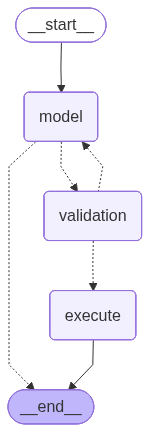

In [24]:
builder.compile()

In [25]:
# Testing the flow ---
inputs = [("user", "I want to send $500 to India.")]
res = graph.invoke(inputs)

for msg in res:
    msg.pretty_print()

================================ Human Message =================================

I want to send $500 to India.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Okay, to send $500 to India, we can use the WireTransfer tool:'}, {'type': 'tool_use', 'name': 'WireTransfer', 'input': {'amount': 500, 'destination_country': 'India'}, 'id': 'tooluse_2zqLwlKcItSTVDsLJvcBa2'}]
Tool Calls:
  WireTransfer (tooluse_2zqLwlKcItSTVDsLJvcBa2)
 Call ID: tooluse_2zqLwlKcItSTVDsLJvcBa2
  Args:
    amount: 500
    destination_country: India
================================= Tool Message =================================
Name: WireTransfer

{"destination_country":"India","amount":500.0}
================================== Ai Message ==================================

✅ Transfer Processed: $500.0 sent to India.


In [26]:

inputs = [("user", "I want to send $500 to Mordor.")]
res = graph.invoke(inputs)

for msg in res:
    msg.pretty_print()

================================ Human Message =================================

I want to send $500 to Mordor.
================================== Ai Message ==================================

[{'type': 'text', 'text': "Okay, let's initiate a wire transfer:"}, {'type': 'tool_use', 'name': 'WireTransfer', 'input': {'amount': 500, 'destination_country': 'Mordor'}, 'id': 'tooluse_KNILG0bYDw65Z1W4uU4Fzs'}]
Tool Calls:
  WireTransfer (tooluse_KNILG0bYDw65Z1W4uU4Fzs)
 Call ID: tooluse_KNILG0bYDw65Z1W4uU4Fzs
  Args:
    amount: 500
    destination_country: Mordor
================================= Tool Message =================================
Name: WireTransfer

1 validation error for WireTransfer
destination_country
  Value error, Mordor is a restricted destination. Please provide a sanctioned-free country. [type=value_error, input_value='Mordor', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error

Respond after fixing all validation errors.
==